In [8]:
import pandas as pd

In [10]:
df = pd.read_csv('Dataset.csv')
print(df.head())

   Unnamed: 0  Hour    HR  O2Sat  Temp    SBP   MAP   DBP  Resp  EtCO2  ...  \
0           0     0   NaN    NaN   NaN    NaN   NaN   NaN   NaN    NaN  ...   
1           1     1  65.0  100.0   NaN    NaN  72.0   NaN  16.5    NaN  ...   
2           2     2  78.0  100.0   NaN    NaN  42.5   NaN   NaN    NaN  ...   
3           3     3  73.0  100.0   NaN    NaN   NaN   NaN  17.0    NaN  ...   
4           4     4  70.0  100.0   NaN  129.0  74.0  69.0  14.0    NaN  ...   

   Fibrinogen  Platelets    Age  Gender  Unit1  Unit2  HospAdmTime  ICULOS  \
0         NaN        NaN  68.54     0.0    NaN    NaN        -0.02     1.0   
1         NaN        NaN  68.54     0.0    NaN    NaN        -0.02     2.0   
2         NaN        NaN  68.54     0.0    NaN    NaN        -0.02     3.0   
3         NaN        NaN  68.54     0.0    NaN    NaN        -0.02     4.0   
4         NaN      330.0  68.54     0.0    NaN    NaN        -0.02     5.0   

   SepsisLabel  Patient_ID  
0          0.0     17072.0 

In [11]:
df.shape

(546123, 44)

In [12]:
df.columns

Index(['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP',
       'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
       'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID'],
      dtype='str')

In [13]:
df.isna().sum()

Unnamed: 0               0
Hour                     0
HR                   42123
O2Sat                65804
Temp                361612
SBP                  83203
MAP                  55596
DBP                 261452
Resp                 53448
EtCO2               546123
BaseExcess          489645
HCO3                502248
FiO2                469548
pH                  483938
PaCO2               498561
SaO2                519443
AST                 537944
BUN                 501673
Alkalinephos        538173
Calcium             518937
Chloride            500815
Creatinine          509911
Bilirubin_direct    545305
Glucose             479815
Lactate             527440
Magnesium           503732
Phosphate           518517
Potassium           487114
Bilirubin_total     539405
TroponinI           545435
Hct                 481844
Hgb                 498055
PTT                 519684
WBC                 505194
Fibrinogen          541959
Platelets           510532
Age                      1
G

In [14]:
# 1. Drop columns with 100% missing values (like EtCO2)
df.drop(columns=['Unnamed: 0', 'EtCO2'], inplace=True)

# 2. Drop the single row with missing SepsisLabel/Patient_ID (likely a file end error)
df.dropna(subset=['SepsisLabel', 'Patient_ID'], inplace=True)

# 3. Convert Patient_ID to string/category for grouping
df['Patient_ID'] = df['Patient_ID'].astype(str)

In [15]:
# List of clinical/lab features to fill
features_to_fill = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 
                    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 
                    'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 
                    'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 
                    'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 
                    'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets']

# Forward fill within each patient
df[features_to_fill] = df.groupby('Patient_ID')[features_to_fill].ffill()

# Fill remaining NaNs (at the start of a patient stay) with global median
df[features_to_fill] = df[features_to_fill].fillna(df[features_to_fill].median())

In [16]:
# Create "Shock Index" (HR / SBP) - a common clinical derived feature
df['Shock_Index'] = df['HR'] / df['SBP']

# Create 3-hour rolling mean for vitals (captures stability)
vitals = ['HR', 'Temp', 'MAP']
for feat in vitals:
    df[f'{feat}_rolling_3h'] = df.groupby('Patient_ID')[feat].transform(lambda x: x.rolling(3, min_periods=1).mean())

# Create "Change" features (difference from previous hour)
df['HR_diff'] = df.groupby('Patient_ID')['HR'].diff().fillna(0)

In [24]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['Patient_ID']))

train_df = df.iloc[train_idx]
test_df = df.iloc[test_idx]

X_train = train_df.drop(columns=['SepsisLabel', 'Patient_ID'])
y_train = train_df['SepsisLabel']
X_test = test_df.drop(columns=['SepsisLabel', 'Patient_ID'])
y_test = test_df['SepsisLabel']

In [17]:
# Check the imbalance ratio
imbalance = df['SepsisLabel'].value_counts(normalize=True) * 100
print(f"Percentage of Sepsis (1): {imbalance[1]:.2f}%")
print(f"Percentage of Non-Sepsis (0): {imbalance[0]:.2f}%")

# Calculate the weight for XGBoost
ratio = df['SepsisLabel'].value_counts()[0] / df['SepsisLabel'].value_counts()[1]
print(f"Recommended scale_pos_weight: {ratio:.2f}")

Percentage of Sepsis (1): 2.17%
Percentage of Non-Sepsis (0): 97.83%
Recommended scale_pos_weight: 45.09


In [25]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc, confusion_matrix

# --- 1. Train XGBoost ---
print("Training XGBoost...")
xgb_model = XGBClassifier(
    scale_pos_weight=45.09, # Your calculated weight
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1 # Uses all CPU cores
)
xgb_model.fit(X_train, y_train)

# --- 2. Train CatBoost ---
print("Training CatBoost...")
cat_model = CatBoostClassifier(
    auto_class_weights='Balanced', # Automatically calculates the 45:1 ratio internally
    iterations=200,
    depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=0 # Keeps the console clean
)
cat_model.fit(X_train, y_train)

Training XGBoost...
Training CatBoost...


CatBoostClassifier(auto_class_weights='Balanced', depth=6, iterations=200, learning_rate=0.05, random_state=42, verbose=0)


--- XGBoost Performance ---
PR-AUC Score: 0.090 (Higher is better for imbalanced data)

Classification Report:
               precision    recall  f1-score   support

No Sepsis (0)       0.99      0.86      0.92    108551
   Sepsis (1)       0.08      0.53      0.14      2414

     accuracy                           0.86    110965
    macro avg       0.53      0.69      0.53    110965
 weighted avg       0.97      0.86      0.90    110965



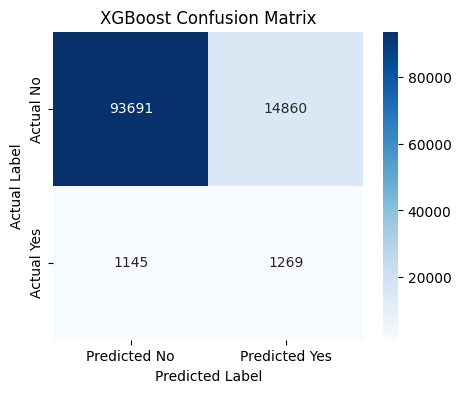


--- CatBoost Performance ---
PR-AUC Score: 0.109 (Higher is better for imbalanced data)

Classification Report:
               precision    recall  f1-score   support

No Sepsis (0)       0.99      0.82      0.90    108551
   Sepsis (1)       0.07      0.64      0.13      2414

     accuracy                           0.82    110965
    macro avg       0.53      0.73      0.52    110965
 weighted avg       0.97      0.82      0.88    110965



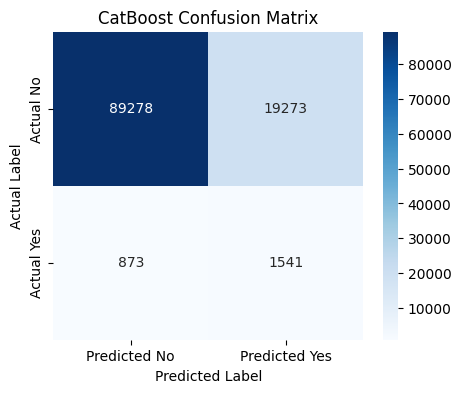

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, name, X_test, y_test):
    # Get probabilities and predictions
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    # Calculate Precision-Recall Curve (PR-AUC)
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    print(f"\n--- {name} Performance ---")
    print(f"PR-AUC Score: {pr_auc:.3f} (Higher is better for imbalanced data)")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Sepsis (0)', 'Sepsis (1)']))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predicted No', 'Predicted Yes'], 
                yticklabels=['Actual No', 'Actual Yes'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Run the evaluation
evaluate_model(xgb_model, "XGBoost", X_test, y_test)
evaluate_model(cat_model, "CatBoost", X_test, y_test)





In [27]:
df.describe()

,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,BaseExcess,HCO3,...,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Shock_Index,HR_rolling_3h,Temp_rolling_3h,MAP_rolling_3h,HR_diff
count,546122.000000,546122.000000,546122.000000,546122.000000,546122.000000,546122.000000,546122.000000,546122.000000,546122.000000,546122.000000,...,274708.000000,274708.000000,546122.000000,546122.000000,546122.000000,546122.000000,546122.000000,546122.000000,546122.000000,546122.000000
mean,25.287527,84.840853,97.203885,36.940710,120.889642,78.937114,60.085550,18.747053,0.007542,24.323804,...,0.507477,0.492523,-52.003997,27.159966,0.021698,0.724640,84.850271,36.936109,78.946868,-0.008485
std,27.764871,16.847303,3.221073,0.716434,21.172191,14.973239,10.584506,5.322863,3.124605,3.885497,...,0.499945,0.499945,148.651563,28.070839,0.145697,0.201738,16.038456,0.686736,13.264695,7.677420
min,0.000000,20.000000,20.000000,21.000000,22.000000,20.000000,20.000000,1.000000,-32.000000,0.000000,...,0.000000,0.000000,-3710.660000,1.000000,0.000000,0.126582,20.000000,21.000000,20.000000,-132.000000
25%,9.000000,73.000000,96.000000,36.500000,106.000000,69.000000,56.000000,15.000000,0.000000,22.000000,...,0.000000,0.000000,-38.010000,11.000000,0.000000,0.584192,73.666667,36.533333,69.666667,-3.000000
50%,20.000000,84.000000,98.000000,36.940000,119.000000,77.000000,59.000000,18.000000,0.000000,24.000000,...,1.000000,0.000000,-2.590000,21.000000,0.000000,0.705882,84.000000,36.940000,77.000000,0.000000
75%,33.000000,95.000000,99.000000,37.390000,134.000000,87.670000,62.000000,22.000000,0.000000,26.000000,...,1.000000,1.000000,-0.020000,35.000000,0.000000,0.836538,95.000000,37.333333,86.666667,3.000000
max,335.000000,223.000000,100.000000,42.220000,274.000000,300.000000,298.000000,69.000000,44.000000,55.000000,...,1.000000,1.000000,23.990000,336.000000,1.000000,4.269231,221.000000,42.036667,275.666667,169.000000


In [31]:
df.Age

0         68.54
1         68.54
2         68.54
3         68.54
4         68.54
          ...  
546117    70.93
546118    70.93
546119    70.93
546120    70.93
546121    70.93
Name: Age, Length: 546122, dtype: float64

In [32]:
# 1. Filter rows where Age is less than 1, then count unique Patient_IDs
neonatal_count = df[df['Age'] < 1]['Patient_ID'].nunique()

print(f"Number of neonatal/infant patients (Age < 1): {neonatal_count}")

# 2. Just to be absolutely sure, let's look at the 5 youngest patients in the dataset
youngest_patients = df.groupby('Patient_ID')['Age'].first().nsmallest(5)
print("\nYoungest ages in the dataset:")
print(youngest_patients)

Number of neonatal/infant patients (Age < 1): 0

Youngest ages in the dataset:
Patient_ID
718.0      18.11
12689.0    18.13
4434.0     18.14
19064.0    18.24
3588.0     18.32
Name: Age, dtype: float64


In [33]:
import numpy as np

# Get the raw probabilities from CatBoost
y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

# Calculate precision and recall for all possible thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_cat)

# Find the threshold where Recall is at least 0.80 (80%)
# We look for the first index where recall drops below 0.80, and take the one right before it
idx = np.where(recall >= 0.80)[0][-1]
optimal_threshold = thresholds[idx]

print(f"To achieve 80% Recall, we must lower the threshold to: {optimal_threshold:.4f}")
print(f"At this threshold, expected Precision will be: {precision[idx]:.4f}")

# Apply the new threshold
y_pred_optimal = (y_prob_cat >= optimal_threshold).astype(int)

print("\n--- CatBoost Performance at Optimal Threshold ---")
print(classification_report(y_test, y_pred_optimal, target_names=['No Sepsis (0)', 'Sepsis (1)']))

To achieve 80% Recall, we must lower the threshold to: 0.3378
At this threshold, expected Precision will be: 0.0431

--- CatBoost Performance at Optimal Threshold ---
               precision    recall  f1-score   support

No Sepsis (0)       0.99      0.60      0.75    108551
   Sepsis (1)       0.04      0.80      0.08      2414

     accuracy                           0.61    110965
    macro avg       0.52      0.70      0.42    110965
 weighted avg       0.97      0.61      0.74    110965



In [34]:
from sklearn.ensemble import VotingClassifier

print("Training Soft Voting Ensemble (XGBoost + CatBoost)...")

# Create the ensemble model
# voting='soft' means it averages the predicted probabilities
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_model), 
        ('cat', cat_model)
    ],
    voting='soft'
)

# Fit the ensemble (this will be fast since the base models are already tuned)
ensemble_model.fit(X_train, y_train)

# Get the averaged probabilities
y_prob_ensemble = ensemble_model.predict_proba(X_test)[:, 1]

# Calculate PR-AUC for the Ensemble
precision_ens, recall_ens, thresholds_ens = precision_recall_curve(y_test, y_prob_ensemble)
pr_auc_ens = auc(recall_ens, precision_ens)

print(f"\n--- Ensemble Performance ---")
print(f"Ensemble PR-AUC Score: {pr_auc_ens:.3f}")

# Find the threshold for 80% Recall on the ENSEMBLE
idx_ens = np.where(recall_ens >= 0.80)[0][-1]
opt_thresh_ens = thresholds_ens[idx_ens]

print(f"\nTo achieve 80% Recall with the Ensemble, threshold is: {opt_thresh_ens:.4f}")
print(f"At this threshold, expected Precision is: {precision_ens[idx_ens]:.4f}")

# Apply the new threshold and show the final report
y_pred_ens_opt = (y_prob_ensemble >= opt_thresh_ens).astype(int)
print("\n--- Ensemble Classification Report (80% Recall Targeted) ---")
print(classification_report(y_test, y_pred_ens_opt, target_names=['No Sepsis (0)', 'Sepsis (1)']))

Training Soft Voting Ensemble (XGBoost + CatBoost)...

--- Ensemble Performance ---
Ensemble PR-AUC Score: 0.100

To achieve 80% Recall with the Ensemble, threshold is: 0.3054
At this threshold, expected Precision is: 0.0434

--- Ensemble Classification Report (80% Recall Targeted) ---
               precision    recall  f1-score   support

No Sepsis (0)       0.99      0.61      0.75    108551
   Sepsis (1)       0.04      0.80      0.08      2414

     accuracy                           0.61    110965
    macro avg       0.52      0.70      0.42    110965
 weighted avg       0.97      0.61      0.74    110965

